---
# CRITICAL REGIME ANALYSIS TOOL  
---
### PURPOSE:
Performs Critical Regime Analysis (CRA) on SISSO-derived descriptors by partitioning materials into physico-chemical regimes and quantifying how each descriptor controls the target property within each regime.

### ANALYSES PERFORMED:
1. Pearson correlation screening of input descriptors
2. Property-value-based regime partitioning (LOW / MID / HIGH)
3. Parallel Coordinates Map Connecting Input properties to Target Mean Values for different Regimes
4. Dominance Analysis  -- standardised regression coefficients × incremental R²
5. Tunability Analysis -- normalised descriptor-to-response coupling index vs Target CV%

**All results are exported to a single multi-sheet Excel workbook.**

### REQUIREMENTS:
- Python 3.12+
- Libraries: numpy, pandas, matplotlib, scikit-learn, scipy, seaborn, openpyxl, xlsxwriter.
- See README/SETUP.md for installation instructions.

### USAGE:
1. Run:  python sisso_regime_analysis.py
2. Follow the interactive prompts to:
* Specify your Excel file location
* Optionally load a symbol_conversion.txt for LaTeX labels
* Select descriptor, SISSO-term, and target columns
* Define any coupled descriptor groups (if present)
* Choose output folder and sub-folder name
* Set target-band thresholds (or accept defaults)

### SYMBOL FILE FORMAT  (symbol_conversion.txt, one entry per line):
- SM = ```$G_\mathrm{VRH}$```
- D = ```$\rho$```
- Lines starting with # are ignored.

### REGIME PARTITIONING  (quantile / percentile of materials, $\alpha$ = 0.15):
- LOW  : bottom 15 % of materials  [min  ...  quantile(0.15)]
- MID  : central 15 % of materials [quantile(0.425)  ...  quantile(0.575)]
- HIGH : top    15 % of materials  [quantile(0.85)  ...  max]

### TARGET BAND DEFAULTS (for plot colouring only, user-overridable):
- LOW band  : target < quantile(0.15) of the target distribution
- HIGH band : target >= quantile(0.85) of the target distribution


                     SISSO CRITICAL REGIME ANALYSIS  v1.1                     


[1] Select data file
------------------------------------------------------------


  Data folder path:  C:/



Available files:
  [1] AFLOW_cleaned_dataset.csv
  [2] CRA_data.csv
  [3] MP_cleaned_dataset.csv
  [4] SISSO_postprocessing_input_data.xlsx


  Select file number [1–4]:  2


✓ Selected: CRA_data.csv
✓ Loaded CSV (11,353 rows × 10 columns)


...

✓ Output folder : C:/CRA
✓ File prefix   : Debye_Temperature

[3] Compute regime windows
------------------------------------------------------------

Regime width (quantile fraction):
  - Default = 0.15 (recommended)
  - Smaller → more critical/extreme regimes (less data)
  - Larger  → more data but weaker regime distinction


Enter ALPHA (α) (press Enter for default 0.15):  0.15


✓ Using ALPHA = 0.150
✓ 27 regime combinations generated

ℹ    SM
      LOW : 0.124  –  17.46
      MID : 36.34  –  50
      HIGH: 90.77  –  510.5
ℹ    YM
      LOW : 0.3574  –  45.7
      MID : 94.14  –  128.8
      HIGH: 231.1  –  1064
ℹ    VPA
      LOW : 5.609  –  12.95
      MID : 16.88  –  19.36
      HIGH: 26.27  –  115.7
ℹ    D
      LOW : 0.3843  –  4.169
      MID : 6.69  –  7.916
      HIGH: 11.04  –  22.36

[4] Run regime analyses
------------------------------------------------------------
✓ 17 regimes analysed  |  10 skipped

  Target band thresholds for plot colouring (low | mid | high).
  Default : low < 342.98  (bottom 15% of value range),  high ≥ 1826.94  (top 15% of value range)


  Use custom thresholds? (y/N) [Preferred: y]:  y
    Low  threshold (< this = LOW band)  :  350
    High threshold (≥ this = HIGH band) :  1000


ℹ  Band thresholds: LOW < 350.00  |  HIGH ≥ 1000.00

[5] Generate plots
------------------------------------------------------------


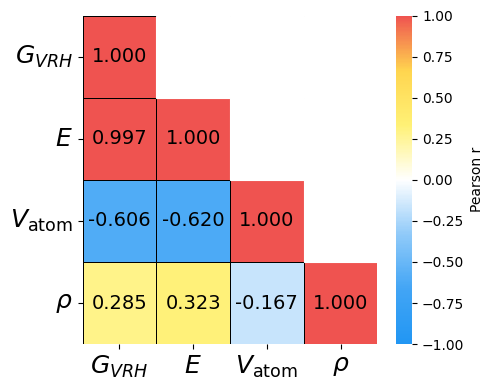

✓ Saved: Debye_Temperature_Plot_Correlation_Heatmap.png + .pdf


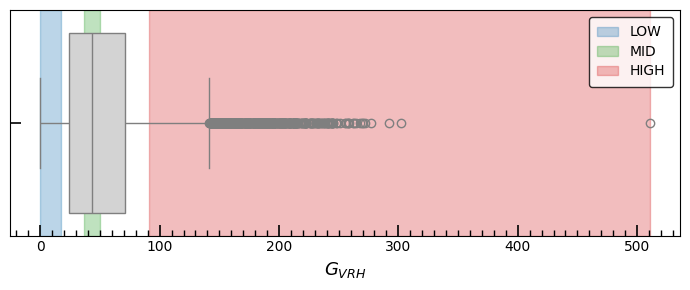

✓ Saved: Debye_Temperature_Plot_Distribution_SM.png + .pdf


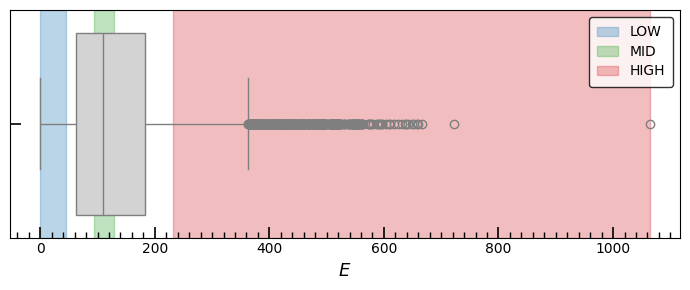

✓ Saved: Debye_Temperature_Plot_Distribution_YM.png + .pdf


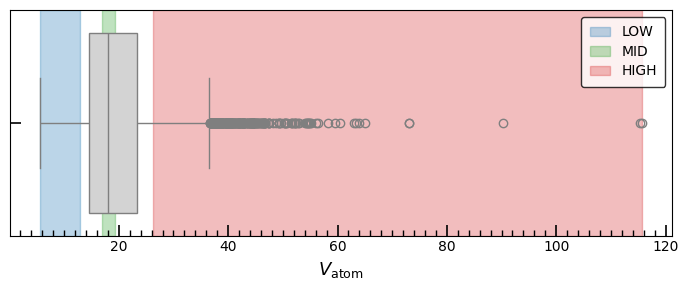

✓ Saved: Debye_Temperature_Plot_Distribution_VPA.png + .pdf


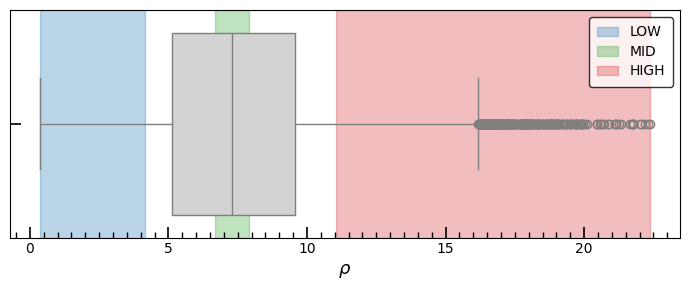

✓ Saved: Debye_Temperature_Plot_Distribution_D.png + .pdf


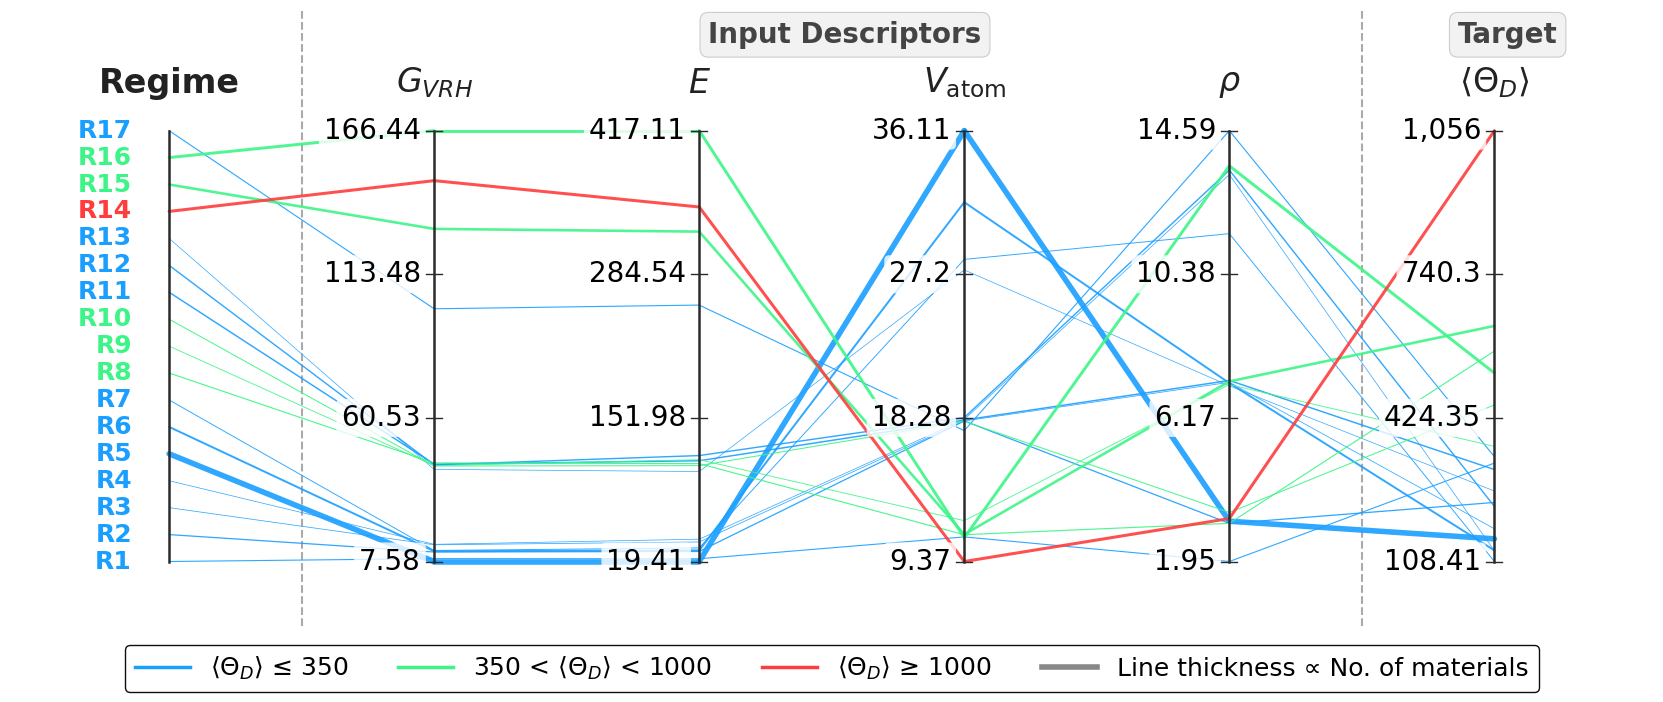

✓ Saved: Debye_Temperature_Plot_ParallelCoordinates.png + .pdf
ℹ  Auto vertex assignment (by mean dominance %):
ℹ    Vertex 1: Term_Moduli  (mean 𝔇 = 67.5%)
ℹ    Vertex 2: Term_Mass_density  (mean 𝔇 = 29.9%)
ℹ    Vertex 3: Term_Interatomic_spacing  (mean 𝔇 = 2.6%)


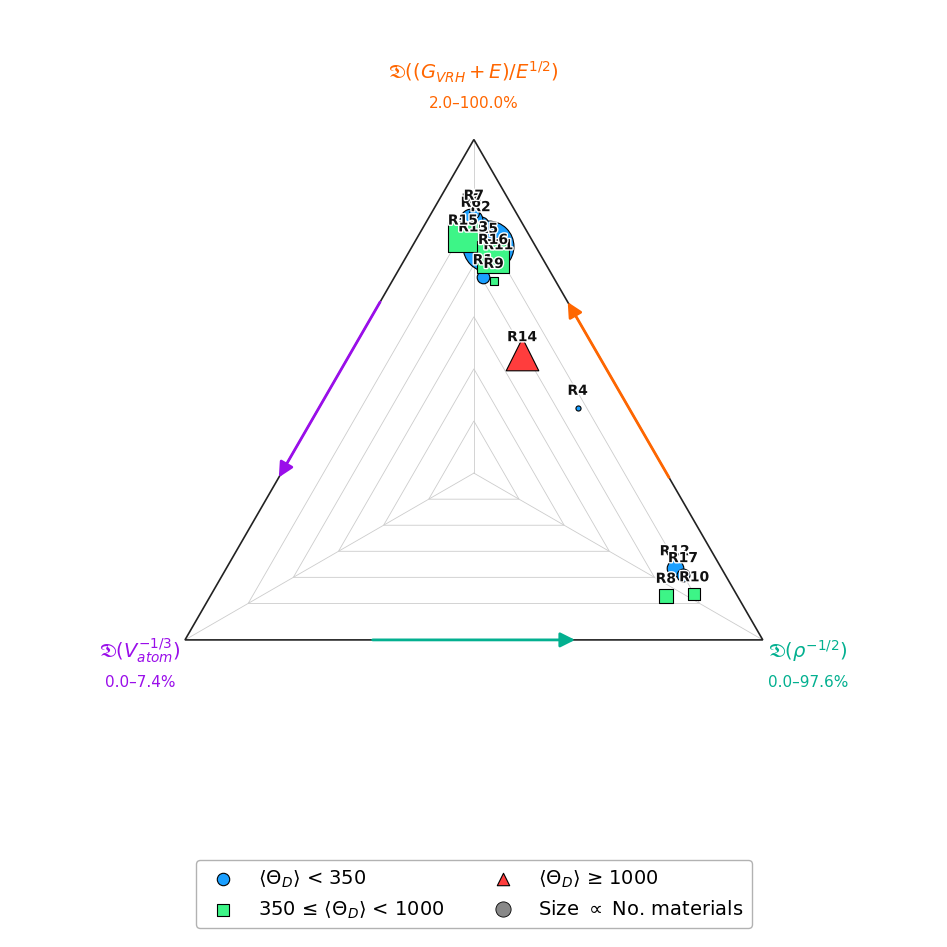

✓ Saved: Debye_Temperature_Plot_Dominance_Map.png + .pdf


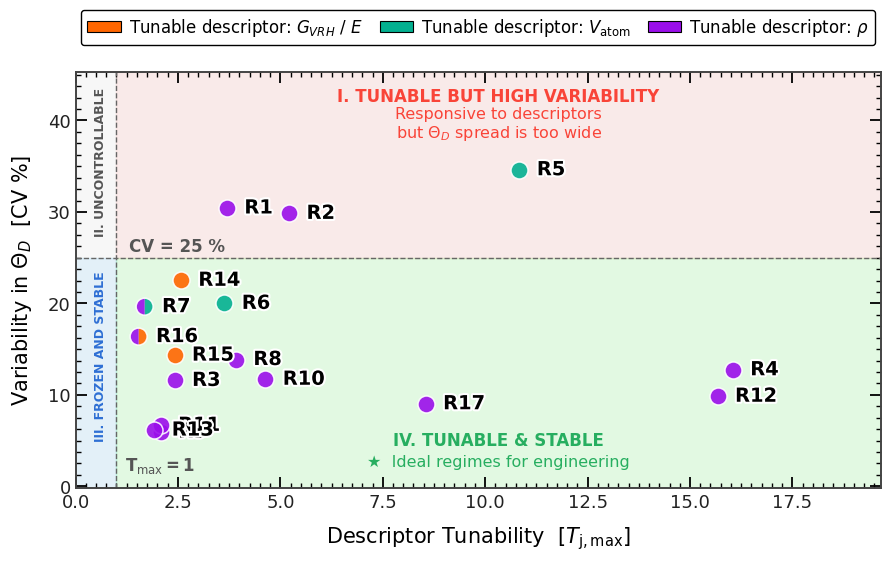

✓ Saved: Debye_Temperature_Plot_Tunability_vs_CV.png + .pdf

[6] Export Excel workbook
------------------------------------------------------------
ℹ  Exporting results → C:/CRA\Debye_Temperature_SISSO_Regime_Analysis.xlsx
✓ Saved: Debye_Temperature_SISSO_Regime_Analysis.xlsx  (C:/CRA\Debye_Temperature_SISSO_Regime_Analysis.xlsx)

                              ANALYSIS COMPLETE                               

  Materials analysed  : 11,353
  Valid regimes       : 17
  Skipped regimes     : 10
  Output directory    : C:/CRA
  Excel sheets        : Regime_Summary | Descriptor_Stats | SISSO_Stats |
                        Target_Stats | Dominance_Analysis | Tunability_Analysis |
                        Regime_Windows | Skipped_Combinations |
                        Global_Statistics | Full_Dataset


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
from __future__ import annotations
import os
import sys
import re
import warnings
from itertools import product
from pathlib import Path
 
warnings.filterwarnings("ignore")
 
# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Polygon as MplPolygon
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import griddata
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
 
# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
mpl.rcParams["font.family"] = "sans-serif"
 
 
# =============================================================================
# COLORS FOR PLOTS
# =============================================================================
_CLR = {
    "bg":        "#ffffff",
    "panel":     "#f9f9f9",
    "spine":     "#444444",
    "dim":       "#666666",
    "text":      "#222222",
    "div":       "#888888",
    # Target-band colours used in parallel coords and dominance map
    "band_low":  "#1a9fff",
    "band_mid":  "#3df587",
    "band_high": "#ff3d3d",
    # Tunability quadrant fills (informational only)
    "q_tunable":  "#00FF00",
    "q_inert":    "#069AF3",
    "q_unstable": "#FC5A50",
    "q_undef":    "#e8e8e8",
}
 
# Colour palette for descriptor groups (tunability plot, dominance vertex colours)
_PALETTE = [
    "#FF6600", "#03B090", "#9A0EEA", "#ffd11a",
    "#a855f7", "#ff8800", "#00c8c8", "#ff6eb4",
]
 
# =============================================================================
# TERMINAL COLOURS
# =============================================================================
class _C:
    """ANSI colour helpers for terminal output."""
    H = "\033[95m"; B = "\033[94m"; G = "\033[92m"
    Y = "\033[93m"; R = "\033[91m"; E = "\033[0m"; BOLD = "\033[1m"
 
    @classmethod
    def header(cls, t):  print(f"\n{cls.H}{cls.BOLD}{'='*78}\n{t.center(78)}\n{'='*78}{cls.E}\n")
    @classmethod
    def ok(cls, t):      print(f"{cls.G}✓ {t}{cls.E}")
    @classmethod
    def warn(cls, t):    print(f"{cls.Y}⚠  {t}{cls.E}")
    @classmethod
    def err(cls, t):     print(f"{cls.R}✗  {t}{cls.E}")
    @classmethod
    def info(cls, t):    print(f"{cls.B}ℹ  {t}{cls.E}")
    @classmethod
    def step(cls, n, t): print(f"\n{cls.B}{cls.BOLD}[{n}] {t}\n{'-'*60}{cls.E}")

# =============================================================================
# SYMBOL LOADER
# =============================================================================
def load_symbol_map(path: str | None) -> dict[str, str]:
    """
    Read an optional symbol_conversion.txt and return a col→LaTeX dict.
    
    Load symbol_conversion.txt from either:
    - a direct file path
    - a directory containing the file

    Silent fallback: returns empty dict if not found.
    """
    sym: dict[str, str] = {}

    if not path:
        return sym

    p = Path(path)

    # Case 1: direct file path
    if p.is_file():
        file_path = p

    # Case 2: directory → look for symbol_conversion.txt inside
    elif p.is_dir():
        file_path = p / "symbol_conversion.txt"
        if not file_path.is_file():
            return sym

    # Invalid path
    else:
        return sym

    # Read file
    with open(file_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" in line:
                key, _, val = line.partition("=")
                sym[key.strip()] = val.strip()

    return sym
 
def display_label(col: str, sym: dict[str, str]) -> str:
    """Return the display label for a column (LaTeX if available, else raw name)."""
    return sym.get(col, col)
 
# =============================================================================
# UTILITY HELPERS
# =============================================================================
def _prompt_int(prompt: str, lo: int, hi: int) -> int:
    """Prompt until the user enters an integer in [lo, hi]."""
    while True:
        try:
            v = int(input(f"  {prompt} [{lo}–{hi}]: "))
            if lo <= v <= hi:
                return v
            _C.err(f"Enter a number between {lo} and {hi}.")
        except ValueError:
            _C.err("Please enter an integer.")
 
def _parse_list(s: str) -> list[str]:
    """Split a comma-separated string into a stripped list of non-empty tokens."""
    return [x.strip() for x in s.split(",") if x.strip()]

def _get_t(entry) -> float:
    """Extract tunability index T from a dict-valued or legacy float entry."""
    if isinstance(entry, dict):
        return float(entry.get("T", np.nan))
    try:
        return float(entry)
    except (TypeError, ValueError):
        return np.nan

def _save_fig(fig: plt.Figure, folder: str, name: str,
              prefix: str = "") -> None:
    """Save figure as 600 dpi PNG and vector PDF, then close it.
    If prefix is given the filename becomes  <prefix>_<name>.
    """
    fname = f"{prefix}_{name}" if prefix else name
    base  = os.path.join(folder, fname)
    fig.savefig(base + ".png", dpi=600, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    fig.savefig(base + ".pdf", bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show(fig)
    _C.ok(f"Saved: {fname}.png + .pdf")

# =============================================================================
# CORE ANALYSIS CLASSES
# =============================================================================
# Contains classes named:
#   DataLoader         — file / sheet selection (Excel or CSV)
#   ColumnSelector     — descriptor / pre-computed SISSO terms / target / coupled-group selection
#   SISSOEvaluator     — interactive definition of composite SISSO terms
#   RegimePartitioner  — property-value-based regime windows + combination list
#   DominanceAnalyzer  — standardised OLS + incremental-R² dominance metric
#   TunabilityAnalyzer — normalised descriptor-to-response coupling index
#   RegimeAnalyzer     — orchestrates per-regime statistics
# =============================================================================
 
class DataLoader:
    """Prompts the user to pick a data file (Excel or CSV) and loads it."""

    @staticmethod
    def pick_file(folder: str) -> str:
        files = sorted(
            p for p in Path(folder).iterdir()
            if p.suffix.lower() in {".xlsx", ".xls", ".xlsm", ".csv"}
        )

        if not files:
            _C.err("No Excel/CSV files found in that folder.")
            sys.exit(1)

        print("\nAvailable files:")
        for i, f in enumerate(files, 1):
            print(f"  [{i}] {f.name}")

        idx = _prompt_int("Select file number", 1, len(files))
        selected = files[idx - 1]

        _C.ok(f"Selected: {selected.name}")
        return str(selected)

    @staticmethod
    def load_data(file_path: str) -> pd.DataFrame:
        ext = Path(file_path).suffix.lower()

        # ---------------- CSV ----------------
        if ext == ".csv":
            df = pd.read_csv(file_path)
            _C.ok(f"Loaded CSV ({len(df):,} rows × {len(df.columns)} columns)")
            return df

        # ---------------- Excel ----------------
        elif ext in {".xlsx", ".xls", ".xlsm"}:
            return DataLoader._pick_sheet_excel(file_path)

        else:
            _C.err("Unsupported file format.")
            sys.exit(1)

    @staticmethod
    def _pick_sheet_excel(excel_path: str) -> pd.DataFrame:
        xls = pd.ExcelFile(excel_path)

        print("\nAvailable sheets:")
        for i, s in enumerate(xls.sheet_names, 1):
            print(f"  [{i}] {s}")

        idx = _prompt_int("Select sheet number", 1, len(xls.sheet_names))
        sheet = xls.sheet_names[idx - 1]

        df = pd.read_excel(excel_path, sheet_name=sheet)
        _C.ok(f"Loaded sheet '{sheet}' ({len(df):,} rows × {len(df.columns)} columns)")

        return df

class ColumnSelector:
    """
    Interactive prompt to identify:
      - primitive descriptors  (input features for regime partitioning)
      - pre-computed SISSO terms (optional; can be defined later in SISSOEvaluator)
      - target variable
      - coupled descriptor groups (descriptors that always co-vary and must share
        the same LOW/MID/HIGH level in every regime combination)
    """
 
    @staticmethod
    def select(
        df_cols: list[str],
    ) -> tuple[list[str], list[str], str, list[list[str]]]:
        _C.step("A", "Column selection")
        preview = ", ".join(df_cols[:15]) + (" …" if len(df_cols) > 15 else "")
        print(f"Columns: {preview}\n")
 
        prim_desc   = _parse_list(input("  Primitive descriptors (Input properties, comma-separated): "))
        sisso_input = input(
            "  SISSO terms column names — if already present in file (comma-separated, or Enter to skip and enter manually later): "
        ).strip()
        sisso_terms = _parse_list(sisso_input) if sisso_input else []
        target      = input("  Target variable column name: ").strip()
 
        coupled: list[list[str]] = []
        print(
            "\n  Coupled descriptor groups (descriptors that always co-vary, e.g. G/SM, E/YM).\n"
            "  Enter one group per line; press Enter on an empty line to finish."
        )
        while True:
            grp = input("    Group (or Enter to finish): ").strip()
            if not grp:
                break
            coupled.append(_parse_list(grp))
 
        _C.ok(f"Descriptors : {prim_desc}")
        _C.ok(f"SISSO terms : {sisso_terms if sisso_terms else '(none yet)'}")
        _C.ok(f"Target      : {target}")
        _C.ok(f"Coupled     : {coupled if coupled else 'none'}")
        return prim_desc, sisso_terms, target, coupled
 
class SISSOEvaluator:
    """
    Allows the user to interactively define composite SISSO descriptor terms
    using arithmetic expressions over existing DataFrame columns. 
    Supported operators : + - * / **
    Supported functions : exp, sqrt, cbrt, log, log10, abs, sin, cos, tan
    Absolute-value bars : |expr|  (automatically converted to abs(expr))
    """
 
    _SAFE_ENV: dict = {
        "np":       np,
        "__builtins__": {},
        "exp":   np.exp,   "sqrt":  np.sqrt,  "cbrt":  np.cbrt,
        "log":   np.log,   "log10": np.log10, "abs":   np.abs,
        "sin":   np.sin,   "cos":   np.cos,   "tan":   np.tan,
    }
 
    @classmethod
    def define_and_evaluate(
        cls,
        df:          pd.DataFrame,
        descriptors: list[str],
    ) -> tuple[pd.DataFrame, list[str]]:
        _C.step("B", "Define SISSO composite terms")
        print(f"  Available columns : {', '.join(descriptors)}")
        print("  Operators         : +  -  *  /  **")
        print("  Functions         : exp(.)  sqrt(.)  cbrt(.)  log(.)  log10(.)  abs(.)  sin(.)  cos(.)  tan(.)")
 
        n     = _prompt_int("  Number of SISSO terms to define", 0, 50)
        names: list[str] = []
        for i in range(n):
            name = input(f"    Term {i+1} name    : ").strip()
            expr = input(f"    Term {i+1} formula : ").strip()
            # Convert |…| bars to abs(…)
            expr = re.sub(r"\|([^|]+)\|", r"abs(\1)", expr)
            env  = {**cls._SAFE_ENV, **{c: df[c] for c in df.columns}}
            try:
                df[name] = eval(expr, env)   # noqa: S307
                names.append(name)
                _C.ok(f"  {name} = {expr}")
            except Exception as exc:
                _C.err(f"  Could not evaluate '{name}': {exc}")
                df[name] = np.nan
                names.append(name)
        return df, names
 
class RegimePartitioner:
    """
    Defines LOW / MID / HIGH windows for each descriptor using material percentiles (quantile-based):

      LOW  : bottom ALPHA quantile of the material distribution
             [min  …  quantile(ALPHA)]

      MID  : central ALPHA window centred on the median
             [quantile(0.5 − ALPHA/2)  …  quantile(0.5 + ALPHA/2)]

      HIGH : top ALPHA quantile of the material distribution
             [quantile(1 − ALPHA)  …  max]

    Default:
      ALPHA = 0.15  →  each window spans 15% of materials

    Interpretation:
      Smaller ALPHA → more *critical/extreme* regimes (less data, sharper physics)
      Larger ALPHA  → more *statistically stable* regimes (more data, less selectivity)

    Coupled descriptors always share the same level (leader drives the group).
    """

    DEFAULT_ALPHA = 0.15
    ALPHA = DEFAULT_ALPHA   # active value used everywhere

    @staticmethod
    def get_alpha_from_user() -> float:
        print("\nRegime width (quantile fraction):")
        print("  - Default = 0.15 (recommended)")
        print("  - Smaller → more critical/extreme regimes (less data)")
        print("  - Larger  → more data but weaker regime distinction")

        try:
            user_input = input(
                fr"Enter ALPHA (α) (press Enter for default {RegimePartitioner.DEFAULT_ALPHA}): "
            ).strip()

            if user_input == "":
                alpha = RegimePartitioner.DEFAULT_ALPHA
            else:
                alpha = float(user_input)

                if not (0 < alpha < 0.5):
                    raise ValueError

        except ValueError:
            _C.warn("Invalid input. Using default ALPHA = 0.15")
            alpha = RegimePartitioner.DEFAULT_ALPHA

        # Set it globally for the class
        RegimePartitioner.ALPHA = alpha

        _C.ok(f"Using ALPHA = {alpha:.3f}")
        return alpha
    
    @classmethod
    def windows(cls, series: pd.Series) -> dict[str, tuple[float, float]]:
        """Return {level: (lo, hi)} dict for a single descriptor series."""
        a = cls.ALPHA

        return {
            "LOW":  (float(series.min()),               float(series.quantile(a))),
            "MID":  (float(series.quantile(0.5 - a/2)), float(series.quantile(0.5 + a/2))),
            "HIGH": (float(series.quantile(1.0 - a)),   float(series.max())),
        }  

    @classmethod
    def all_combinations(
        cls,
        descriptors: list[str],
        windows:     dict[str, dict[str, tuple[float, float]]],
        coupled:     list[list[str]],
    ) -> list[dict[str, str]]:
        """
        Generate every LOW/MID/HIGH combination for independent descriptors,
        then propagate levels to coupled followers.
        """
        followers: set[str] = {d for g in coupled for d in g[1:]}
        leaders             = [d for d in descriptors if d not in followers]
 
        combos: list[dict[str, str]] = []
        for levels in product(["LOW", "MID", "HIGH"], repeat=len(leaders)):
            combo: dict[str, str] = dict(zip(leaders, levels))
            # Propagate leader level to followers in the same coupled group
            for g in coupled:
                ldr = g[0]
                if ldr in combo:
                    for fol in g[1:]:
                        combo[fol] = combo[ldr]
            # Any descriptor not assigned gets MID as a neutral default
            for d in descriptors:
                if d not in combo:
                    combo[d] = "MID"
            combos.append(combo)
        return combos
 
# =============================================================================
# DOMINANCE ANALYZER
# =============================================================================
class DominanceAnalyzer:
    """
    Computes per-term dominance within a regime subset using:
      β*_j  (beta) — standardised regression coefficient (z-scored X and y)
      ΔR²_j (dr2) — incremental R² lost when term j is dropped (leave-one-out)
      𝔇_j   (dom_pct) — dominance percentage = |β*_j| × ΔR²_norm_j  (normalised, sums to 100%)
      VIF_j  (vif) — variance inflation factor (flag if > 5)
      
    Returns a dict keyed by SISSO term name with all metrics.
    """
 
    MIN_SAMPLES = 3   # minimum number of data points to attempt regression
 
    @staticmethod
    def _ols_r2(X: np.ndarray, y: np.ndarray) -> float:
        """Fit OLS and return R²; returns 0 for degenerate cases."""
        if X.shape[1] == 0:
            return 0.0
        reg    = LinearRegression(fit_intercept=True).fit(X, y)
        ss_res = np.sum((y - reg.predict(X)) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0
 
    @classmethod
    def compute(
        cls,
        subset:      pd.DataFrame,
        sisso_terms: list[str],
        target:      str,
    ) -> dict[str, dict]:
        """Compute dominance metrics for all sisso_terms on the given subset."""
        empty = {
            t: {
                "beta_std":      np.nan, "delta_r2":     np.nan,
                "delta_r2_norm": np.nan, "vif":          np.nan,
                "dominance_pct": np.nan, "dominant":     False,
                "role":          "insufficient data",
                "vif_flag":      False,
            }
            for t in sisso_terms
        }
 
        cols_ok = [t for t in sisso_terms if t in subset.columns]
        valid   = subset[cols_ok + [target]].dropna()
        n, p    = len(valid), len(cols_ok)
 
        if n < cls.MIN_SAMPLES or p == 0:
            return empty
 
        # Z-score both X and y for standardised coefficients
        sx = StandardScaler()
        sy = StandardScaler()
        Xz = sx.fit_transform(valid[cols_ok].values.astype(float))
        yz = sy.fit_transform(valid[[target]].values.astype(float)).ravel()
 
        try:
            reg_full = LinearRegression(fit_intercept=True).fit(Xz, yz)
            beta     = reg_full.coef_
            r2_full  = cls._ols_r2(Xz, yz)
        except Exception:
            return empty
 
        # Incremental R² (leave-one-out)
        dr2 = np.array([
            max(
                r2_full - (cls._ols_r2(
                    Xz[:, [k for k in range(p) if k != j]], yz
                ) if p > 1 else 0.0),
                0.0,
            )
            for j in range(p)
        ])
 
        sum_dr2 = dr2.sum()
        dr2_n   = dr2 / sum_dr2 if sum_dr2 > 0 else np.zeros(p)
 
        # Dominance percentage: weight by both coefficient magnitude and unique R²
        w       = np.abs(beta) * dr2_n
        sum_w   = w.sum()
        dom_pct = w / sum_w * 100.0 if sum_w > 0 else np.zeros(p)
        dom_idx = int(np.argmax(dom_pct)) if sum_w > 0 else -1
 
        # Variance inflation factors
        vif = []
        for j in range(p):
            if p == 1:
                vif.append(1.0)
            else:
                r2j = cls._ols_r2(
                    Xz[:, [k for k in range(p) if k != j]], Xz[:, j]
                )
                vif.append(1.0 / (1.0 - r2j) if r2j < 1.0 else np.inf)
 
        result: dict[str, dict] = {}
        for j, t in enumerate(cols_ok):
            result[t] = {
                "beta_std":      float(beta[j]),
                "delta_r2":      float(dr2[j]),
                "delta_r2_norm": float(dr2_n[j]),
                "vif":           float(vif[j]),
                "dominance_pct": float(dom_pct[j]),
                "dominant":      j == dom_idx,
                "role":          "dominant" if j == dom_idx else "secondary",
                "vif_flag":      bool(vif[j] > 5),
            }
        # Fill NaN entries for any term that was missing from the subset
        for t in sisso_terms:
            if t not in result:
                result[t] = empty[t]
        return result
 
# =============================================================================
# TUNABILITY ANALYZER
# =============================================================================
class TunabilityAnalyzer:
    """
    Computes the normalised Tunability index T_j for each primitive descriptor:
 
        T_j = (ΔD_j / G_j)  /  p_eff
        
        p_eff = mean_{k≠j}(ΔD_k / G_k)
 
    where  ΔD_j = range of descriptor j within this regime subset
           G_j  = global range of descriptor j across the entire dataset
 
    T_j > 1  : descriptor varies more than average within this regime  → tunable
    T_j < 1  : descriptor is relatively frozen within this regime      → limited
    T_j ≈ 0  : descriptor is essentially constant within this regime   → inert
    """
 
    @staticmethod
    def compute(
        subset:        pd.DataFrame,
        descriptors:   list[str],
        global_ranges: dict[str, dict],
    ) -> dict[str, float]:
        """
        Return a dict keyed by descriptor name, each value containing ALL
        intermediate tunability quantities:
 
          desc_min        : min of descriptor within this regime
          desc_max        : max of descriptor within this regime
          desc_range      : max - min within regime  (ΔD_j, raw)
          global_min      : global min of descriptor across full dataset
          global_max      : global max of descriptor across full dataset
          global_range    : global max - min  (G_j)
          delta_d_norm    : ΔD_j / G_j  (normalised within-regime spread)
          p_eff           : mean(ΔD_k / G_k) for all other descriptors k ≠ j
          T               : tunability index = delta_d_norm / p_eff
          tunable         : True if T > 1
        """
        # First pass: compute normalised range for every descriptor
        norm_ranges: dict[str, float] = {}
        raw_ranges:  dict[str, float] = {}
        for desc in descriptors:
            if desc not in subset.columns:
                norm_ranges[desc] = np.nan
                raw_ranges[desc]  = np.nan
                continue
            gr     = global_ranges.get(desc, {})
            g_span = gr.get("max", np.nan) - gr.get("min", np.nan)
            if not g_span or np.isnan(g_span):
                norm_ranges[desc] = np.nan
                raw_ranges[desc]  = np.nan
                continue
            d_range           = float(subset[desc].max() - subset[desc].min())
            raw_ranges[desc]  = d_range
            norm_ranges[desc] = d_range / g_span
 
        # Second pass: build full detail dict for each descriptor
        result: dict[str, dict] = {}
        for desc in descriptors:
            gr     = global_ranges.get(desc, {})
            g_min  = gr.get("min", np.nan)
            g_max  = gr.get("max", np.nan)
            g_span = g_max - g_min if not (np.isnan(g_min) or np.isnan(g_max)) else np.nan
 
            if desc not in subset.columns or np.isnan(g_span) or g_span == 0:
                result[desc] = {
                    "desc_min":     np.nan, "desc_max":     np.nan,
                    "desc_range":   np.nan, "global_min":   g_min,
                    "global_max":   g_max,  "global_range": g_span,
                    "delta_d_norm": np.nan, "p_eff":        np.nan,
                    "T":            np.nan, "tunable":      False,
                }
                continue
 
            d_min  = float(subset[desc].min())
            d_max  = float(subset[desc].max())
            d_range = raw_ranges[desc]
            delta_d = norm_ranges[desc]
 
            # p_eff: mean normalised range of all other descriptors
            others = [
                v for k, v in norm_ranges.items()
                if k != desc and not np.isnan(v)
            ]
            p_eff = float(np.mean(others)) if others else np.nan
            T_val = float(delta_d / p_eff) if (p_eff and p_eff > 0) else np.nan
 
            result[desc] = {
                "desc_min":     d_min,
                "desc_max":     d_max,
                "desc_range":   d_range,
                "global_min":   g_min,
                "global_max":   g_max,
                "global_range": g_span,
                "delta_d_norm": delta_d,
                "p_eff":        p_eff,
                "T":            T_val,
                "tunable":      bool(T_val > 1) if not np.isnan(T_val) else False,
            }
        return result
 
# =============================================================================
# REGIME ANALYZER
# =============================================================================
class RegimeAnalyzer:
    """
    Orchestrates all per-regime computations for a single material subset:
      - Descriptor and target descriptive statistics
      - Coefficient of variation (CV%) of the target
      - Tunability indices
      - Bivariate R² of each SISSO term vs target
      - Dominance analysis (standardised OLS + incremental R²)
    """
 
    def __init__(
        self,
        descriptors:   list[str],
        sisso_terms:   list[str],
        target:        str,
        global_ranges: dict[str, dict],
    ):
        self.descriptors   = descriptors
        self.sisso_terms   = sisso_terms
        self.target        = target
        self.global_ranges = global_ranges
 
    @staticmethod
    def _stats(s: pd.Series) -> dict:
        """Return a dict of basic descriptive statistics for a Series."""
        return {
            "min":   s.min(),  "max":   s.max(),
            "mean":  s.mean(), "std":   s.std(),
            "range": s.max() - s.min(),
        }
 
    def analyze(self, subset: pd.DataFrame, combo: dict[str, str]) -> dict:
        """Run all analyses for one regime subset and return a results dict."""
        res: dict = {
            "regime_combination": combo,
            "material_count":     len(subset),
            "descriptor_stats":   {},
            "sisso_stats":        {},
            "target_stats":       {},
            "target_cv":          np.nan,
            "tunability":         {},
            "sisso_r2":           {},
            "dominance":          {},
        }
 
        for d in self.descriptors:
            if d in subset.columns:
                res["descriptor_stats"][d] = self._stats(subset[d].dropna())
 
        for t in self.sisso_terms:
            if t in subset.columns:
                res["sisso_stats"][t] = self._stats(subset[t].dropna())
 
        if self.target in subset.columns:
            tgt = subset[self.target].dropna()
            res["target_stats"] = self._stats(tgt)
            mu  = res["target_stats"]["mean"]
            res["target_cv"] = (
                float(tgt.std() / abs(mu) * 100) if mu != 0 else np.nan
            )

        res["tunability"] = TunabilityAnalyzer.compute(
            subset, self.descriptors, self.global_ranges
        )
 
        if self.target in subset.columns:
            for t in self.sisso_terms:
                if t not in subset.columns:
                    res["sisso_r2"][t] = np.nan
                    continue
                valid = subset[[t, self.target]].dropna()
                if len(valid) >= 2:
                    _, _, r, _, _ = linregress(valid[t], valid[self.target])
                    res["sisso_r2"][t] = float(r ** 2)
                else:
                    res["sisso_r2"][t] = np.nan
 
        res["dominance"] = DominanceAnalyzer.compute(
            subset, self.sisso_terms, self.target
        )
        return res

# =============================================================================
# SECTION 3 — PLOT FUNCTIONS & EXCEL EXPORTER
# =============================================================================
# Contains:
#   _wedge_path                  — helper: sector marker path
#   _draw_marker                 — helper: multi-colour split marker
#   _tc / _outer_pt / _edge_pt  — helper: ternary/polygon coordinate utilities
#   plot_correlation_heatmap     — supplementary: Pearson correlation matrix
#   plot_descriptor_distributions— supplementary: box + regime-band overlays
#   plot_parallel_coordinates    — Plot A: multi-axis regime lines
#   plot_dominance_map           — Plot B: polygon dominance map 
#   plot_tunability_vs_cv        — Plot C: tunability vs CV% scatter
#   export_excel                 — 10-sheet Excel workbook export
# =============================================================================
 
 
# =============================================================================
# SHARED DRAWING HELPERS
# =============================================================================
def _wedge_path(t1_deg: float, t2_deg: float, n: int = 60) -> MplPath:
    """Return a pie-wedge MplPath for use as a scatter marker."""
    th = np.linspace(np.radians(t1_deg), np.radians(t2_deg), n)
    v  = [(0.0, 0.0)] + list(zip(np.cos(th), np.sin(th))) + [(0.0, 0.0)]
    c  = [MplPath.MOVETO] + [MplPath.LINETO] * n + [MplPath.CLOSEPOLY]
    return MplPath(v, c)
 
 
def _draw_marker(ax, x, y, size, colours, lw=1.1, zo=4):
    """
    Draw a single scatter marker at (x, y).
    If multiple colours are supplied the marker is split into equal wedge sectors.
    """
    if not colours:
        colours = ["#aaaaaa"]
    n = len(colours)
    if n == 1:
        ax.scatter(x, y, s=size, color=colours[0],
                   edgecolors="white", linewidths=lw, zorder=zo, alpha=0.9)
        return
    step = 360.0 / n
    for k, fc in enumerate(colours):
        ax.scatter(
            x, y, s=size,
            marker=_wedge_path(k * step - 90, (k + 1) * step - 90),
            color=fc, edgecolors="none", linewidths=0, zorder=zo, alpha=0.9,
        )
    # White edge ring on top
    ax.scatter(x, y, s=size, color="none",
               edgecolors="white", linewidths=lw, zorder=zo + 1, alpha=0.9)
 
 
def _poly_vertices(n: int, scale: float = 1.0) -> np.ndarray:
    """Return n evenly-spaced polygon vertices starting at the top (π/2)."""
    angles = np.pi / 2 - 2 * np.pi * np.arange(n) / n
    return scale * np.column_stack([np.cos(angles), np.sin(angles)])
 
 
def _bary_to_cart(weights: np.ndarray, vertices: np.ndarray) -> np.ndarray:
    """Map barycentric weights (shape N×k) to Cartesian coordinates via polygon vertices."""
    return weights @ vertices
 
 
def _point_in_polygon(px: np.ndarray, py: np.ndarray,
                      verts: np.ndarray) -> np.ndarray:
    """Boolean mask: True where (px, py) lies inside the convex polygon defined by verts."""
    n   = len(verts)
    pts = np.column_stack([px.ravel(), py.ravel()])
    inside = np.ones(len(pts), dtype=bool)
    for i in range(n):
        ax_, ay_ = verts[i]
        bx,  by  = verts[(i + 1) % n]
        cross = (bx - ax_) * (pts[:, 1] - ay_) - (by - ay_) * (pts[:, 0] - ax_)
        inside &= (cross >= 0)
    return inside.reshape(px.shape)
 
 
# =============================================================================
# SUPPLEMENTARY PLOT — CORRELATION HEATMAP
# =============================================================================
def plot_correlation_heatmap(
    df:          pd.DataFrame,
    descriptors: list[str],
    sym:         dict[str, str],
    output_dir:  str,
    prefix:      str = "",
) -> None:
    """Lower-triangular Pearson correlation heatmap for the primitive descriptors."""
    labels = [display_label(d, sym) for d in descriptors]
    cmap   = LinearSegmentedColormap.from_list(
        "custom_RdBu",
        ["#2196F3", "#42A5F5", "#90CAF9", "#FFFFFF",
         "#FFF176", "#FFD54F", "#EF5350"],
        N=256,
    )
    corr = df[descriptors].corr(method="pearson")
    N    = len(descriptors)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # hide upper triangle
 
    fig, ax = plt.subplots(
        figsize=(max(5, N * 0.5), max(4, N * 1.0)),
        facecolor="white",
    )
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".3f",
        cmap=cmap, vmin=-1, vmax=1, center=0,
        linewidths=0.4, linecolor="black",
        annot_kws={"size": 14, "color": "black"},
        cbar_kws={"label": "Pearson r", "shrink": 1.0},
        xticklabels=labels, yticklabels=labels, ax=ax,
    )
    # White-out upper-triangle cells
    for i in range(N):
        for j in range(N):
            if j > i:
                ax.add_patch(
                    Rectangle((j, i), 1, 1, fill=True, color="white",
                               zorder=2, linewidth=0.8, edgecolor="#cccccc")
                )
    ax.tick_params(axis="both", labelsize=18, rotation=0)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("semibold")
        lbl.set_color("black")
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    _save_fig(fig, output_dir, "Plot_Correlation_Heatmap", prefix)
 
 
# =============================================================================
# SUPPLEMENTARY PLOT — DESCRIPTOR DISTRIBUTIONS
# =============================================================================
def plot_descriptor_distributions(
    df:          pd.DataFrame,
    descriptors: list[str],
    windows:     dict[str, dict],
    sym:         dict[str, str],
    output_dir:  str,
    prefix:      str = "",
) -> None:
    """
    One horizontal box plot per descriptor overlaid with coloured LOW/MID/HIGH
    regime band spans.
    """
    colours = {"LOW": "#1f77b4", "MID": "#2ca02c", "HIGH": "#d62728"}
    for d in descriptors:
        fig, ax = plt.subplots(figsize=(7, 3), facecolor="white")
        sns.boxplot(x=df[d].dropna(), orient="h", color="lightgray", ax=ax)
        for lbl, (lo, hi) in windows[d].items():
            ax.axvspan(lo, hi, color=colours[lbl], alpha=0.3, label=lbl)
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(which="major", direction="in", length=8, width=1.2)
        ax.tick_params(which="minor", direction="in", length=4, width=1.0)
        ax.set_xlabel(display_label(d, sym), fontsize=13, fontweight="bold")
        ax.legend(fontsize=10, frameon=True, fancybox=True, framealpha=0.80, edgecolor="black", facecolor="white", borderpad=0.6, labelspacing=0.4, handlelength=1.5)
        plt.tight_layout()
        safe_name = re.sub(r"[^A-Za-z0-9_]", "_", d)
        _save_fig(fig, output_dir, f"Plot_Distribution_{safe_name}", prefix)

# =============================================================================
# PLOT A — PARALLEL COORDINATES
# =============================================================================
def plot_parallel_coordinates(
    results:      list[dict],
    descriptors:  list[str],
    target:       str,
    sym:          dict[str, str],
    output_dir:   str,
    target_bands: tuple[float, float] = (350.0, 1000.0),
    prefix:       str = "",
) -> None:
    """
    Multi-axis parallel coordinates plot.
    One line per regime; line colour encodes target band; thickness ∝ N materials.
    """
    band_lo, band_hi = target_bands
    band_col = {
        "low":  _CLR["band_low"],
        "mid":  _CLR["band_mid"],
        "high": _CLR["band_high"],
    }
 
    def _band(v: float) -> str:
        if np.isnan(v):    return "mid"
        if v < band_lo:    return "low"
        if v > band_hi:    return "high"
        return "mid"
 
    def _norm(v: float, vmin: float, vmax: float) -> float:
        return (v - vmin) / (vmax - vmin) if vmax > vmin else 0.5
 
    def _fmt(v: float) -> str:
        if v == 0:          return "0"
        a = abs(v)
        if a >= 1000:       return f"{v:,.0f}"
        if a >= 1:          return f"{v:.2f}".rstrip("0").rstrip(".")
        if a >= 0.001:      return f"{v:.4f}".rstrip("0").rstrip(".")
        return f"{v:.2e}"
 
    target_key = f"{target}_mean"
    axes       = ["Regime"] + list(descriptors) + [target_key]
    n_ax       = len(axes)
 
    # ── Assemble row data ─────────────────────────────────────────────────────
    rows: list[dict] = []
    for i, r in enumerate(results):
        row: dict = {
            "Regime":    i + 1,
            "_id":       r.get("id", f"R{i+1}"),
            "_n":        r.get("material_count", 1),
        }
        for d in descriptors:
            row[d] = r["descriptor_stats"].get(d, {}).get("mean", np.nan)
        row[target_key] = r.get("target_stats", {}).get("mean", np.nan)
        td = row[target_key]
        row["_band"] = _band(float(td) if not (td != td) else np.nan)
        rows.append(row)
 
    if not rows:
        _C.warn("No data for parallel coordinates — skipping.")
        return
 
    df_plot = pd.DataFrame(rows)
 
    # ── Per-axis value ranges ─────────────────────────────────────────────────
    ax_info: dict[str, dict] = {}
    for name in axes:
        vals = df_plot[name].dropna()
        if len(vals) == 0:
            ax_info[name] = {"vmin": 0.0, "vmax": 1.0}
            continue
        vmin, vmax = float(vals.min()), float(vals.max())
        if vmin == vmax:
            vmin, vmax = vmin - 0.5, vmax + 0.5
        ax_info[name] = {"vmin": vmin, "vmax": vmax}
 
    # ── Line-width scaling ────────────────────────────────────────────────────
    n_vals           = [r["_n"] for r in rows]
    n_lo, n_hi       = min(n_vals), max(n_vals)
    lw_range         = (0.5, 4.0)
 
    def _lw(n: int) -> float:
        if n_hi == n_lo:
            return float(np.mean(lw_range))
        return lw_range[0] + (lw_range[1] - lw_range[0]) * (n - n_lo) / (n_hi - n_lo)
 
    # ── Figure setup ──────────────────────────────────────────────────────────
    fig_w = max(18, n_ax * 1.7)
    fig, ax = plt.subplots(figsize=(fig_w, 8.0), facecolor=_CLR["bg"])
    ax.set_facecolor(_CLR["bg"])
    ax.set_xlim(-0.6, n_ax - 0.4)
    ax.set_ylim(-0.15, 1.28)
    ax.axis("off")
 
    x_pos  = np.linspace(0, n_ax - 1, n_ax)
    N_TICKS = 4
 
    # ── Draw vertical axes and tick labels ────────────────────────────────────
    for xi, name in zip(x_pos, axes):
        ax.plot([xi, xi], [0, 1], color="#2B2B2B", lw=1.8, zorder=3)
        # Build display label
        label = display_label(
            name.replace(f"_{target.split('_')[-1]}", "").replace("_mean", ""),
            sym,
        )
        if name == target_key:
            label = f"$\\langle${display_label(target, sym)}$\\rangle$"
        ax.text(xi, 1.07, label,
                ha="center", va="bottom", fontsize=24,
                fontweight="bold", color=_CLR["text"])
        if name == "Regime":
            continue
        info = ax_info[name]
        for k in range(N_TICKS):
            pct = k / (N_TICKS - 1)
            raw = info["vmin"] + pct * (info["vmax"] - info["vmin"])
            ax.plot([xi - 0.03, xi + 0.03], [pct, pct],
                    color="#2B2B2B", lw=1.0, zorder=4)
            ax.text(xi - 0.05, pct, _fmt(raw),
                    ha="right", va="center", fontsize=20, color="#000000",
                    bbox=dict(boxstyle="round,pad=0.18", facecolor="white",
                              edgecolor="none", alpha=0.80))
 
    # ── Draw lines per target band ────────────────────────────────────────────
    for band in ("low", "mid", "high"):
        for row in rows:
            if row["_band"] != band:
                continue
            ys = []
            ok = True
            for name in axes:
                v = row.get(name, np.nan)
                try:
                    fv = float(v)
                except (TypeError, ValueError):
                    ok = False; break
                if np.isnan(fv):
                    ok = False; break
                info = ax_info[name]
                ys.append(_norm(fv, info["vmin"], info["vmax"]))
            if not ok:
                continue
            col  = band_col[band]
            segs = [
                [[x_pos[j], ys[j]], [x_pos[j + 1], ys[j + 1]]]
                for j in range(n_ax - 1)
            ]
            lc = LineCollection(
                segs, colors=[col] * len(segs),
                linewidths=_lw(row["_n"]), alpha=0.9, zorder=2, capstyle="round",
            )
            ax.add_collection(lc)
            ax.text(x_pos[0] - 0.14, ys[0], row["_id"],
                    ha="right", va="center", fontsize=18,
                    color=col, fontweight="bold")
 
    # ── Section headers and dividers ──────────────────────────────────────────
    sec_edges  = [0.5, len(descriptors) + 0.5]
    sec_labels = ["Input Descriptors", "Target"]
    sec_starts = [1, len(descriptors) + 1]
    sec_ends   = [len(descriptors), n_ax - 1]
 
    for xb in sec_edges:
        ax.axvline(xb, color="#AAAAAA", lw=1.5, ls="--", zorder=1)
    for lbl, xs, xe in zip(sec_labels, sec_starts, sec_ends):
        mid = (x_pos[xs] + x_pos[xe] + 0.1) / 2
        ax.text(mid, 1.19, lbl, ha="center", va="bottom", fontsize=20,
                fontweight="bold", color="#444444",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#F2F2F2",
                          edgecolor="#CCCCCC", lw=0.8))
 
    # ── Legend ────────────────────────────────────────────────────────────────
    leg = [
        Line2D([0], [0], color=band_col[b], lw=2.5, label=lbl)
        for b, lbl in zip(
            ("low", "mid", "high"),
            (
                f"$\\langle${display_label(target, sym)}$\\rangle$ ≤ {band_lo:.0f}",
                f"{band_lo:.0f} < $\\langle${display_label(target, sym)}$\\rangle$ < {band_hi:.0f}",
                f"$\\langle${display_label(target, sym)}$\\rangle$ ≥ {band_hi:.0f}",
            ),
        )
    ]
    leg.append(Line2D([0], [0], color="#888888", lw=lw_range[1],
                      label="Line thickness ∝ No. of materials"))
    ax.legend(handles=leg, loc="upper center", bbox_to_anchor=(0.5, -0.01),
              ncol=min(4, len(leg)), fontsize=18, framealpha=0.95,
              facecolor="white", edgecolor="black", handlelength=2.2)
 
    plt.tight_layout(rect=[0.03, 0.07, 0.97, 0.96])
    _save_fig(fig, output_dir, "Plot_ParallelCoordinates", prefix)

# =============================================================================
# PLOT B — POLYGON DOMINANCE MAP  (automatic vertex assignment)
# =============================================================================
def _auto_assign_vertices(
    results:     list[dict],
    sisso_terms: list[str],
) -> list[str]:
    """
    Assign SISSO terms to polygon vertices automatically by sorting on mean
    dominance percentage (descending), placing the highest-dominance term at
    the top vertex and distributing the rest clockwise.
 
    This avoids cluttered, manually-entered assignments and ensures the most
    dominant term always anchors the most prominent position.
    """
    mean_dom: dict[str, float] = {}
    for t in sisso_terms:
        vals = []
        for r in results:
            d = r.get("dominance", {}).get(t, {})
            v = d.get("dominance_pct", np.nan)
            if not np.isnan(float(v)) if v == v else False:
                vals.append(float(v))
        mean_dom[t] = float(np.mean(vals)) if vals else 0.0
 
    # Sort descending; top vertex gets the highest-dominance term
    ordered = sorted(sisso_terms, key=lambda t: mean_dom[t], reverse=True)
 
    _C.info("Auto vertex assignment (by mean dominance %):")
    for i, t in enumerate(ordered):
        _C.info(f"  Vertex {i+1}: {t}  (mean 𝔇 = {mean_dom[t]:.1f}%)")
    return ordered
 
 
def plot_dominance_map(
    results:      list[dict],
    sisso_terms:  list[str],
    target:       str,
    sym:          dict[str, str],
    output_dir:   str,
    target_bands: tuple[float, float] = (350.0, 1000.0),
    prefix:       str = "",
) -> None:
    """
    Polygon dominance map with automatic vertex assignment.
    Each vertex represents one SISSO term; the interior position of a regime
    marker reflects how strongly each term dominates in that regime.
    Vertex colours and directional arrows identify the terms.
    """
    n_terms = len(sisso_terms)
    if n_terms < 3:
        _C.warn(
            f"Dominance map requires ≥ 3 SISSO terms; got {n_terms} — skipping."
        )
        return
 
    # ── Automatic vertex ordering ─────────────────────────────────────────────
    sisso_terms = _auto_assign_vertices(results, sisso_terms)
 
    band_lo, band_hi = target_bands
    _THETA_COLS   = [_CLR["band_low"], _CLR["band_mid"], _CLR["band_high"]]
    _THETA_MARKS  = ["o", "s", "^"]
    _THETA_LABELS = [
        f"$\\langle${display_label(target, sym)}$\\rangle$ < {band_lo:.0f}",
        f"{band_lo:.0f} \u2264 $\\langle${display_label(target, sym)}"
        f"$\\rangle$ < {band_hi:.0f}",
        f"$\\langle${display_label(target, sym)}$\\rangle$ \u2265 {band_hi:.0f}",
    ]
 
    def _bin(v: float) -> int:
        if v < band_lo: return 0
        if v < band_hi: return 1
        return 2
 
    term_cols = [_PALETTE[i % len(_PALETTE)] for i in range(n_terms)]
 
    # ── Collect valid regime points ───────────────────────────────────────────
    raw_pts: list[dict] = []
    for r in results:
        dom  = r.get("dominance", {})
        dvec = np.array(
            [dom.get(t, {}).get("dominance_pct", np.nan) for t in sisso_terms],
            dtype=float,
        )
        td  = r.get("target_stats", {}).get("mean", np.nan)
        n   = r.get("material_count", 0)
        rid = r.get("id", "")
        if np.any(np.isnan(dvec)) or np.isnan(td):
            continue
        if np.any(dvec < 0) or np.any(dvec > 100):
            continue
        if abs(dvec.sum() - 100.0) > 5.0:
            continue
        raw_pts.append({"d": dvec, "td": float(td), "n": int(n), "id": rid})
 
    if not raw_pts:
        _C.warn("No valid dominance data — skipping dominance map.")
        return
 
    d_arr  = np.array([p["d"]  for p in raw_pts])
    td_arr = np.array([p["td"] for p in raw_pts])
    n_arr  = np.array([p["n"]  for p in raw_pts])
    id_arr = [p["id"] for p in raw_pts]
 
    S    = d_arr.sum(axis=1, keepdims=True) + 1e-12
    bary = d_arr / S
 
    # ── Polygon geometry ──────────────────────────────────────────────────────
    R_IN  = 1.0    # inner polygon radius (barycentric mapping)
    R_OUT = 1.28   # outer polygon radius (drawn border)
 
    verts_in  = _poly_vertices(n_terms, R_IN)
    verts_out = _poly_vertices(n_terms, R_OUT)
 
    cart     = _bary_to_cart(bary, verts_in)
    cx_p     = cart[:, 0]
    cy_p     = cart[:, 1]
    ctr      = np.array([0.0, 0.0])
 
    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 9.5), facecolor=_CLR["bg"])
    ax.set_facecolor(_CLR["bg"])
    ax.set_aspect("equal")
    ax.axis("off")
 
    # ── Background contour fill ───────────────────────────────────────────────
    if len(raw_pts) >= 4:
        margin = R_OUT * 1.05
        gx     = np.linspace(-margin, margin, 350)
        gy     = np.linspace(-margin, margin, 350)
        GX, GY = np.meshgrid(gx, gy)
        inside = _point_in_polygon(GX, GY, verts_out)
        Z      = griddata((cx_p, cy_p), td_arr, (GX, GY), method="linear")
        Z[~inside] = np.nan
        t_max = max(td_arr.max() * 1.01, band_hi + 1)
        ax.contourf(GX, GY, Z,
                    levels=[0, band_lo, band_hi, t_max],
                    colors=["#ddeeff", "#ddf5dd", "#ffe8e8"],
                    alpha=0.55, zorder=3)
 
    # ── Outer polygon border ──────────────────────────────────────────────────
    ax.add_patch(
        MplPolygon(verts_out, closed=True,
                   facecolor="none", edgecolor="#222222",
                   linewidth=1.2, zorder=10)
    )
    ax.add_patch(
        MplPolygon(verts_in, closed=True,
                   facecolor=_CLR["bg"], edgecolor="none",
                   linewidth=0, zorder=2)
    )
 
    # ── Clip path for grid lines ──────────────────────────────────────────────
    clip_verts = np.vstack([verts_out, verts_out[0]])
    codes = (
        [MplPath.MOVETO] +
        [MplPath.LINETO] * (n_terms - 1) +
        [MplPath.CLOSEPOLY]
    )
    clip = PathPatch(
        MplPath(clip_verts, codes),
        facecolor="none", edgecolor="none", transform=ax.transData,
    )
    ax.add_patch(clip)
 
    # ── Radial spokes ─────────────────────────────────────────────────────────
    for v in verts_out:
        ln = ax.plot([ctr[0], v[0]], [ctr[1], v[1]],
                     color="#cccccc", lw=0.6, zorder=5)[0]
        ln.set_clip_path(clip)
 
    # ── Concentric ring grid ──────────────────────────────────────────────────
    for pct in [0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        ring = verts_in * pct
        ln = ax.add_patch(
            MplPolygon(ring, closed=True,
                       facecolor="none", edgecolor="#cccccc",
                       linewidth=0.6, zorder=5)
        )
        ln.set_clip_path(clip)
 
    # ── Vertex labels and arrows (no edge percentage text) ────────────────────
    def _strip_dollars(s: str) -> str:
        s = s.strip()
        return s[1:-1] if (s.startswith("$") and s.endswith("$")) else s
 
    lbl_off = 0.20
    step    = 0.06
 
    for j, term in enumerate(sisso_terms):
        col  = term_cols[j]
        vout = verts_out[j]
        dn   = vout / (np.linalg.norm(vout) + 1e-12)
        base = vout + dn * lbl_off
 
        # Descriptor label above base point
        ax.text(base[0], base[1] + step,
                r"$\mathfrak{D}(" + _strip_dollars(display_label(term, sym)) + r")$",
                ha="center", va="center",
                fontweight="bold", fontsize=14, color=col, zorder=12)
 
        # Dominance range below base point
        dmin = d_arr[:, j].min()
        dmax = d_arr[:, j].max()
        ax.text(base[0], base[1] - step,
                f"{dmin:.1f}–{dmax:.1f}%",
                ha="center", va="center",
                fontweight="normal", fontsize=11, color=col, zorder=12)
 
        # Thick directional arrow along edge (arrow only, no percentage text)
        v_a  = verts_out[j]
        v_b  = verts_out[(j + 1) % n_terms]
        tail = v_a + 0.68 * (v_b - v_a)
        head = v_a + 0.32 * (v_b - v_a)
        ax.annotate(
            "", xy=head, xytext=tail,
            arrowprops=dict(
                arrowstyle="-|>", color=col,
                lw=2.0,                      # thicker arrow shaft
                mutation_scale=22,           # larger arrowhead
            ),
            zorder=10,
        )
 
    # ── Regime markers ────────────────────────────────────────────────────────
    for xi, yi, tdi, ni, rid in zip(cx_p, cy_p, td_arr, n_arr, id_arr):
        bidx = _bin(tdi)
        ax.scatter(xi, yi, s=ni ** 1.25,
                   color=_THETA_COLS[bidx], marker=_THETA_MARKS[bidx],
                   edgecolors="black", linewidths=0.8, alpha=1.0, zorder=7)
        ax.text(xi, yi + 0.038, rid,
                ha="center", va="bottom", fontsize=10,
                color="#111111", fontweight="bold", zorder=8,
                path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
 
    # ── Legend ────────────────────────────────────────────────────────────────
    handles = [
        plt.scatter([], [], s=80, color=_THETA_COLS[i],
                    marker=_THETA_MARKS[i], edgecolors="black",
                    linewidths=0.8, label=_THETA_LABELS[i])
        for i in range(3)
    ]
    handles.append(
        plt.scatter([], [], s=120, color="#888888", marker="o",
                    edgecolors="black", linewidths=0.6,
                    label=r"Size $\propto$ No. materials")
    )
    ax.legend(handles=handles, loc="lower center",
              bbox_to_anchor=(0.5, -0.001),
              ncol=min(2, len(handles)), fontsize=14,
              framealpha=0.9, facecolor="white", edgecolor="#aaaaaa")
 
    pad_ax = R_OUT + lbl_off + 0.30
    ax.set_xlim(-pad_ax, pad_ax)
    ax.set_ylim(-pad_ax, pad_ax)
    plt.tight_layout(pad=0.8)
    _save_fig(fig, output_dir, "Plot_Dominance_Map", prefix)

# =============================================================================
# PLOT C — TUNABILITY vs CV%
# =============================================================================
def plot_tunability_vs_cv(
    results:        list[dict],
    descriptors:    list[str],
    coupled_groups: list[list[str]],
    target:         str,
    sym:            dict[str, str],
    output_dir:     str,
    cv_threshold:   float = 25.0,
    t_threshold:    float = 1.0,
    manual_labels:  dict[str, dict[str, float]] | None = None,
    prefix:         str = "",
) -> None:
    """
    Scatter plot of T_max (maximum descriptor tunability index) vs CV(target).
 
    Quadrants:
      Top-right    — TUNABLE BUT HIGH VARIABILITY  (responsive but noisy)
      Bottom-right — TUNABLE & STABLE              (ideal engineering regimes)
      Top-left     — UNCONTROLLABLE                (not descriptor-driven)
      Bottom-left  — INERT BUT STABLE              (frozen descriptors)
 
    Marker colour encodes which descriptor group is most tunable.
    All markers are drawn at constant size = 150.
 
    Parameters
    ----------
    manual_labels : dict[str, dict[str, float]] | None
        Optional per-regime label position overrides if two labels are overlapping.
        Example: {"R13": {"x_offset": 0.5, "y_offset": -2.0}}
        Omitted regimes use automatic radius-based positioning for labels.
    """
    if manual_labels is None:
        manual_labels = {}
 
    # ── Build descriptor groups ───────────────────────────────────────────────
    groups:   list[frozenset] = []
    assigned: set[str]        = set()
    for g in coupled_groups:
        members = [d for d in g if d in descriptors]
        if members:
            groups.append(frozenset(members))
            assigned.update(members)
    for d in descriptors:
        if d not in assigned:
            groups.append(frozenset([d]))
 
    grp_col = {g: _PALETTE[i % len(_PALETTE)] for i, g in enumerate(groups)}
 
    # ── Collect per-regime quantities ─────────────────────────────────────────
    pts: list[dict] = []
    for i, r in enumerate(results):
        T_map = r.get("tunability", {})
        cv    = r.get("target_cv", np.nan)
        if cv is None or np.isnan(float(cv)):
            continue

        grp_T: dict[frozenset, float] = {}
        for g in groups:
            vals = [
                _get_t(T_map[d])
                for d in g
                if d in T_map and T_map[d] is not None
                and not np.isnan(_get_t(T_map[d]))
            ]
            if vals:
                grp_T[g] = max(vals)
 
        if not grp_T:
            continue
 
        best_g     = max(grp_T, key=grp_T.get)
        T_best     = grp_T[best_g]
        tunable_gs = [g for g, tv in grp_T.items() if tv > t_threshold]
 
        pts.append({
            "T":     T_best,
            "cv":    float(cv),
            "tgrps": tunable_gs,
            "id":    r.get("id", f"R{i+1}"),
        })
 
    if not pts:
        _C.warn("No valid data for Tunability vs CV plot — skipping.")
        return
 
    xs = np.array([p["T"]  for p in pts])
    ys = np.array([p["cv"] for p in pts])
 
    # ── Axis limits ───────────────────────────────────────────────────────────
    x_pad = max((xs.max() - xs.min()) * 0.18, 1.5)
    y_pad = max((ys.max() - ys.min()) * 0.18, 3.5)
    xlo   = 0
    xhi   = max(xs.max() + x_pad + 1, t_threshold + 1.5)
    ylo   = max(-1.0, ys.min() - y_pad - 1)
    yhi   = ys.max() + y_pad + 5.5
 
    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9.5, 6.0), facecolor=_CLR["bg"])
    ax.set_facecolor(_CLR["panel"])
    for sp in ax.spines.values():
        sp.set_edgecolor(_CLR["spine"])
        sp.set_linewidth(1.4)
 
    # ── Quadrant fills ────────────────────────────────────────────────────────
    kw = dict(zorder=0)
    ax.fill_betweenx([cv_threshold, yhi],   t_threshold, xhi,      color="#FC5A50", alpha=0.09, **kw)
    ax.fill_betweenx([ylo, cv_threshold],   t_threshold, xhi,      color="#00FF00", alpha=0.09, **kw)
    ax.fill_betweenx([cv_threshold, yhi],   xlo - 1,    t_threshold, color="#e8e8e8", alpha=0.09, **kw)
    ax.fill_betweenx([ylo, cv_threshold],   xlo - 1,    t_threshold, color="#069AF3", alpha=0.09, **kw)
 
    ax.axvline(t_threshold,  color=_CLR["dim"], lw=1, ls="--", zorder=2)
    ax.axhline(cv_threshold, color=_CLR["dim"], lw=1, ls="--", zorder=2)
 
    # ── Quadrant text labels ──────────────────────────────────────────────────
    mid_r = (t_threshold + xhi) / 2
    mid_l = (xlo + t_threshold) / 2 + 0.1
    py    = (yhi - ylo) * 0.027
 
    ax.text(mid_r, yhi - py - 0.5, "I. TUNABLE BUT HIGH VARIABILITY",
            color="#F94438", ha="center", va="top",
            fontweight="bold", fontsize=12)
    ax.text(mid_r, yhi - py - 2.5,
            f"Responsive to descriptors\nbut {display_label(target, sym)} spread is too wide",
            color="#F94438", ha="center", va="top", fontsize=11.5)
 
    ax.text(mid_r, ylo + py + 3, "IV. TUNABLE & STABLE",
            color="#27ae60", ha="center", va="bottom",
            fontweight="bold", fontsize=12)
    ax.text(mid_r, ylo + py + 2.5, "★  Ideal regimes for engineering",
            color="#27ae60", ha="center", va="top", fontsize=11.5)

    ax.text(mid_l, yhi - py - 0.5, "II. UNCONTROLLABLE", color="#555555",
             ha="center", va="top", fontweight="bold", fontsize=9, rotation=90)
    ax.text(mid_l, ylo + py + 3.9, "III. FROZEN AND STABLE",
             color="#2e6fd4", ha="center", va="bottom", fontweight="bold", fontsize=9, rotation=90)
 
    # ── Threshold annotations ─────────────────────────────────────────────────
    px_ = (xhi - xlo) * 0.016
    ax.text(t_threshold + px_ - 0.1, ylo + (yhi - ylo) * 0.031,
            r"$\mathbf{T_\mathrm{max}=1}$",
            color="#555555", fontsize=12, fontweight="bold", va="bottom")
    ax.text(xlo + px_ + 1, cv_threshold + py - 1,
            f"CV = {cv_threshold:.0f} %",
            color="#555555", fontsize=12, fontweight="bold", va="bottom")
 
    # ── Markers and regime ID labels ──────────────────────────────────────────
    fig.canvas.draw()
    inv  = ax.transData.inverted()
    orig = inv.transform(ax.transData.transform([0, 0]))
 
    for p, xi, yi in zip(pts, xs, ys):
        cols = [grp_col[g] for g in p["tgrps"]] if p["tgrps"] else ["#aaaaaa"]
        _draw_marker(ax, xi, yi, 150, cols, lw=1.1, zo=4)
 
        regime_id = p["id"]
        if regime_id in manual_labels:
            x_offset = manual_labels[regime_id].get("x_offset", 0.0)
            y_offset = manual_labels[regime_id].get("y_offset", 0.0)
            label_x  = xi + x_offset
            label_y  = yi + y_offset
        else:
            radius_px  = (150 ** 0.5) / 2.0
            pt_in_data = inv.transform(
                ax.transData.transform([0, 0]) + np.array([radius_px, 0])
            )
            x_offset   = abs(pt_in_data[0] - orig[0]) + abs(xhi - xlo) * 0.012
            label_x    = xi + x_offset
            label_y    = yi
 
        ax.text(label_x, label_y, regime_id,
                ha="left", va="center", fontsize=14,
                color="black", fontweight="bold", zorder=7,
                path_effects=[pe.withStroke(linewidth=3, foreground="white")])
 
    # ── Legend ────────────────────────────────────────────────────────────────
    handles = []
    for g in groups:
        members = sorted(
            g, key=lambda d: descriptors.index(d) if d in descriptors else 999
        )
        label = " / ".join(display_label(d, sym) for d in members)
        handles.append(
            mpatches.Patch(facecolor=grp_col[g], edgecolor="black",
                           linewidth=0.8,
                           label=f"Tunable descriptor: {label}")
        )
    ax.legend(handles=handles, fontsize=12, framealpha=1,
              facecolor="white", edgecolor="black",
              loc="upper center", bbox_to_anchor=(0.5, 1.17),
              ncol=min(3, len(handles)), columnspacing=1.0, handletextpad=0.5)
 
    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(8))
    ax.tick_params(axis="both", which="major", direction="in",
                   length=8, width=1.3, colors="k",
                   top=True, right=True, labelsize=14.5)
    ax.tick_params(axis="both", which="minor", direction="in",
                   length=3.5, width=1.0, colors="k",
                   top=True, right=True)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(_CLR["text"])
        lbl.set_fontsize(13)
    ax.set_xlabel(r"Descriptor Tunability  [$T_\mathrm{j,max}$]",
                  fontsize=15, color="black", labelpad=10)
    ax.set_ylabel(
        f"Variability in {display_label(target, sym)}  [CV %]",
        fontsize=15, color="black", labelpad=10,
    )
    ax.grid(False)
    plt.tight_layout(pad=1.8)
    _save_fig(fig, output_dir, "Plot_Tunability_vs_CV", prefix)
 
 
# =============================================================================
# EXCEL EXPORTER  (10-sheet workbook)
# =============================================================================
def export_excel(
    results:       list[dict],
    descriptors:   list[str],
    sisso_terms:   list[str],
    target:        str,
    df_full:       pd.DataFrame,
    windows:       dict[str, dict],
    regime_combos: list[dict],
    skipped:       list[dict],
    sym:           dict[str, str],
    output_dir:    str,
    prefix:        str = "",
) -> str:
    """
    Write all analysis results to a single Excel workbook with 10 sheets:
      1  Regime_Summary        — headline metrics per regime
      2  Descriptor_Stats      — min/max/mean/std/range of each descriptor per regime
      3  SISSO_Stats           — same for each SISSO composite term
      4  Target_Stats          — target statistics + CV% per regime
      5  Dominance_Analysis    — full dominance metrics (β*, ΔR², VIF, 𝔇%) per term
      6  Tunability_Analysis   — decriptor deviations + tunability indices + dominance combined per term
      7  Regime_Windows        — LOW/MID/HIGH thresholds for each descriptor
      8  Skipped_Combinations  — combinations that had < 5 materials
      9  Global_Statistics     — dataset-wide descriptive statistics
     10  Full_Dataset          — raw data for all used columns
    """
    xlsx_name = f"{prefix}_SISSO_Regime_Analysis.xlsx" if prefix else "SISSO_Regime_Analysis.xlsx"
    out_path  = os.path.join(output_dir, xlsx_name)
    _C.info(f"Exporting results → {out_path}")
 
    with pd.ExcelWriter(
        out_path, engine="xlsxwriter",
        engine_kwargs={"options": {"nan_inf_to_errors": True}},
    ) as writer:
        wb = writer.book
 
        # ── Cell formats ─────────────────────────────────────────────────────
        fmt_hdr  = wb.add_format({"bold": True, "bg_color": "#1F4E79",
                                   "font_color": "white", "border": 1,
                                   "align": "center", "valign": "vcenter",
                                   "text_wrap": True})
        fmt_dom  = wb.add_format({"bold": True, "bg_color": "#E2EFDA", "border": 1})
        fmt_std  = wb.add_format({"bg_color": "#FFFFFF", "border": 1})
        fmt_vif  = wb.add_format({"bold": True, "bg_color": "#FCE4D6", "border": 1})
        fmt_tun  = wb.add_format({"bold": True, "bg_color": "#FFF2CC", "border": 1})
        fmt_note = wb.add_format({"italic": True, "font_color": "#555555"})
 
        def _write(df: pd.DataFrame, sheet: str, col_w: dict | None = None) -> None:
            df.to_excel(writer, sheet_name=sheet, index=False)
            ws = writer.sheets[sheet]
            for ci, col in enumerate(df.columns):
                w = (col_w or {}).get(col, max(len(str(col)) + 2, 12))
                ws.set_column(ci, ci, w)
                ws.write(0, ci, col, fmt_hdr)
 
        # ── Sheet 1: Regime Summary ───────────────────────────────────────────
        rows = []
        for i, r in enumerate(results, 1):
            dom_dict = r.get("dominance", {})
            dom_term = next(
                (t for t, v in dom_dict.items()
                 if isinstance(v, dict) and v.get("dominant")), ""
            )
            dom_pct = (
                dom_dict.get(dom_term, {}).get("dominance_pct", np.nan)
                if dom_term else np.nan
            )
            T_map  = r.get("tunability", {})
            T_vals = [_get_t(T_map[d]) for d in descriptors
                      if d in T_map and T_map[d] is not None
                      and not np.isnan(_get_t(T_map[d]))]
            T_max  = max(T_vals, default=np.nan)
 
            row: dict = {
                "Regime_ID":           f"R{i}",
                "Material_Count":      r["material_count"],
                "Target_CV_%":         r.get("target_cv", np.nan),
                "Dominant_SISSO_Term": dom_term,
                "Dominant_Term_D_%":   dom_pct,
                "T_max":               T_max,
            }
            for d in descriptors:
                row[f"{d}_Level"] = r["regime_combination"].get(d, "")
            ts = r.get("target_stats", {})
            for k in ("min", "max", "mean", "std", "range"):
                row[f"{target}_{k}"] = ts.get(k, np.nan)
            for t in sisso_terms:
                row[f"R2_{t}"] = r["sisso_r2"].get(t, np.nan)
            rows.append(row)
        _write(pd.DataFrame(rows), "Regime_Summary")
 
        # ── Sheet 2: Descriptor Statistics ────────────────────────────────────
        rows = []
        for i, r in enumerate(results, 1):
            base = {"Regime_ID": f"R{i}", "Material_Count": r["material_count"]}
            for d in descriptors:
                s = r["descriptor_stats"].get(d, {})
                for k in ("min", "max", "mean", "std", "range"):
                    base[f"{d}_{k}"] = s.get(k, np.nan)
            rows.append(base)
        _write(pd.DataFrame(rows), "Descriptor_Stats")
 
        # ── Sheet 3: SISSO Statistics ─────────────────────────────────────────
        rows = []
        for i, r in enumerate(results, 1):
            base = {"Regime_ID": f"R{i}", "Material_Count": r["material_count"]}
            for t in sisso_terms:
                s = r["sisso_stats"].get(t, {})
                for k in ("min", "max", "mean", "std", "range"):
                    base[f"{t}_{k}"] = s.get(k, np.nan)
            rows.append(base)
        _write(pd.DataFrame(rows), "SISSO_Stats")
 
        # ── Sheet 4: Target Statistics ────────────────────────────────────────
        rows = []
        for i, r in enumerate(results, 1):
            ts = r.get("target_stats", {})
            rows.append({
                "Regime_ID":       f"R{i}",
                "Material_Count":  r["material_count"],
                f"{target}_min":   ts.get("min",   np.nan),
                f"{target}_max":   ts.get("max",   np.nan),
                f"{target}_mean":  ts.get("mean",  np.nan),
                f"{target}_std":   ts.get("std",   np.nan),
                f"{target}_range": ts.get("range", np.nan),
                "CV_%":            r.get("target_cv", np.nan),
            })
        _write(pd.DataFrame(rows), "Target_Stats")
 
        # ── Sheet 5: Dominance Analysis ───────────────────────────────────────
        rows = []
        for i, r in enumerate(results, 1):
            for t in sisso_terms:
                d = r.get("dominance", {}).get(t, {})
                rows.append({
                    "Regime_ID":      f"R{i}",
                    "Material_Count": r["material_count"],
                    "SISSO_Term":     t,
                    "beta_std":       d.get("beta_std",      np.nan),
                    "delta_R2":       d.get("delta_r2",      np.nan),
                    "delta_R2_norm":  d.get("delta_r2_norm", np.nan),
                    "VIF":            d.get("vif",           np.nan),
                    "Dominance_pct":  d.get("dominance_pct", np.nan),
                    "Role":           d.get("role",          "—"),
                    "Dominant":       "YES" if d.get("dominant") else "no",
                    "VIF_Warning":    "WARNING" if d.get("vif_flag") else "OK",
                })
        df_dom = pd.DataFrame(rows)
        df_dom.to_excel(writer, sheet_name="Dominance_Analysis", index=False)
        ws_dom = writer.sheets["Dominance_Analysis"]
        col_w_dom = {
            "Regime_ID": 10, "Material_Count": 14, "SISSO_Term": 20,
            "beta_std": 14, "delta_R2": 14, "delta_R2_norm": 16,
            "VIF": 10, "Dominance_pct": 16, "Role": 14,
            "Dominant": 10, "VIF_Warning": 14,
        }
        for ci, col in enumerate(df_dom.columns):
            ws_dom.set_column(ci, ci, col_w_dom.get(col, 16))
            ws_dom.write(0, ci, col, fmt_hdr)
        for ri, row_data in df_dom.iterrows():
            fmt = (fmt_dom if row_data["Dominant"] == "YES"
                   else fmt_vif if row_data["VIF_Warning"] == "WARNING"
                   else fmt_std)
            for ci in range(len(df_dom.columns)):
                ws_dom.write(ri + 1, ci, row_data.iloc[ci], fmt)
        note_row = len(df_dom) + 3
        ws_dom.write(
            note_row, 0,
            "𝔇_j = (|β*_j| × ΔR²_norm_j) / Σ_k(|β*_k| × ΔR²_norm_k) × 100%  "
            "— β*_j: standardised OLS coeff (z-scored)  "
            "— ΔR²_j = R²_full − R²_(all\\Φ_j)  "
            "— VIF > 5: multicollinearity warning",
            fmt_note,
        )
 
        # ── Sheet 6: Tunability Analysis ──────────────────────────────────────
        # One row per descriptor per regime — all intermediate quantities shown.
        tun_rows = []
        for i, r in enumerate(results, 1):
            T_map    = r.get("tunability", {})
            tgt_s    = r.get("target_stats", {})
            T_vals   = [_get_t(T_map[d]) for d in descriptors
                        if d in T_map and T_map[d] is not None
                        and not np.isnan(_get_t(T_map[d]))]
            T_max    = max(T_vals) if T_vals else np.nan
            best_desc = (
                descriptors[
                    [_get_t(T_map[d]) if d in T_map and T_map[d] is not None
                     else -np.inf for d in descriptors].index(T_max)
                ] if T_vals else ""
            )
 
            for d in descriptors:
                td = T_map.get(d, {}) if isinstance(T_map.get(d), dict) else {}
                T_val = td.get("T", np.nan)
                row: dict = {
                    # ── Regime context ────────────────────────────────────────
                    "Regime_ID":           f"R{i}",
                    "Material_Count":      r["material_count"],
                    "Descriptor":          d,
                    "Descriptor_Level":    r["regime_combination"].get(d, ""),
                    # ── Target context ────────────────────────────────────────
                    f"{target}_mean":      tgt_s.get("mean",  np.nan),
                    f"{target}_std":       tgt_s.get("std",   np.nan),
                    "Target_CV_%":         r.get("target_cv", np.nan),
                    # ── Descriptor range within regime ────────────────────────
                    "Desc_Regime_Min":     td.get("desc_min",   np.nan),
                    "Desc_Regime_Max":     td.get("desc_max",   np.nan),
                    "Desc_Regime_Range":   td.get("desc_range", np.nan),
                    # ── Global descriptor range (full dataset) ────────────────
                    "Desc_Global_Min":     td.get("global_min",   np.nan),
                    "Desc_Global_Max":     td.get("global_max",   np.nan),
                    "Desc_Global_Range":   td.get("global_range", np.nan),
                    # ── Tunability calculation steps ──────────────────────────
                    "delta_d_norm":        td.get("delta_d_norm", np.nan),   # ΔD_j / G_j
                    "p_eff":               td.get("p_eff",        np.nan),   # mean ΔD_k/G_k of others
                    "T":                   T_val,                             # T_j = delta_d_norm / p_eff
                    "Tunable":             "YES" if td.get("tunable") else "no",
                    # ── Summary across all descriptors in this regime ─────────
                    "T_max":               T_max,
                    "Most_Tunable_Desc":   best_desc,
                }
                tun_rows.append(row)
 
        df_tun = pd.DataFrame(tun_rows)
        df_tun.to_excel(writer, sheet_name="Tunability_Analysis", index=False)
        ws_tun = writer.sheets["Tunability_Analysis"]
 
        col_w_tun: dict[str, int] = {
            "Regime_ID": 10, "Material_Count": 14,
            "Descriptor": 22, "Descriptor_Level": 16,
            f"{target}_mean": 16, f"{target}_std": 14, "Target_CV_%": 13,
            "Desc_Regime_Min": 16, "Desc_Regime_Max": 16, "Desc_Regime_Range": 18,
            "Desc_Global_Min": 16, "Desc_Global_Max": 16, "Desc_Global_Range": 18,
            "delta_d_norm": 14, "p_eff": 12,
            "T": 10, "Tunable": 10,
            "T_max": 10, "Most_Tunable_Desc": 22,
        }
        for ci, col in enumerate(df_tun.columns):
            ws_tun.set_column(ci, ci, col_w_tun.get(col, max(len(str(col)) + 2, 12)))
            ws_tun.write(0, ci, col, fmt_hdr)
 
        # Row colouring: highlight most-tunable descriptor per regime (T = T_max)
        fmt_best = wb.add_format({"bold": True, "bg_color": "#E2EFDA", "border": 1})
        for ri, row_data in df_tun.iterrows():
            t_val  = row_data.get("T", np.nan)
            t_max  = row_data.get("T_max", np.nan)
            is_best = (
                not (isinstance(t_val, float) and np.isnan(t_val))
                and not (isinstance(t_max, float) and np.isnan(t_max))
                and abs(float(t_val) - float(t_max)) < 1e-9
            )
            row_fmt = fmt_best if is_best else fmt_std
            for ci in range(len(df_tun.columns)):
                ws_tun.write(ri + 1, ci, row_data.iloc[ci], row_fmt)
 
        note_row_tun = len(df_tun) + 3
        ws_tun.write(note_row_tun, 0,
            "delta_d_norm = (Desc_Regime_Range) / (Desc_Global_Range)  "
            "— normalised within-regime spread of this descriptor.",
            fmt_note)
        ws_tun.write(note_row_tun + 1, 0,
            "p_eff = mean(delta_d_norm_k) for all other descriptors k ≠ j  "
            "— effective background spread of the system.",
            fmt_note)
        ws_tun.write(note_row_tun + 2, 0,
            "T_j = delta_d_norm / p_eff  "
            "— Tunability index: T > 1 = tunable; T < 1 = limited; T ≈ 0 = frozen.",
            fmt_note)
        ws_tun.write(note_row_tun + 3, 0,
            "T_max = max(T_j) across all descriptors in this regime.  "
            "Green rows highlight the most tunable descriptor per regime.",
            fmt_note)
 
        # ── Sheet 7: Regime Windows ───────────────────────────────────────────
        rows = []
        for desc, wins in windows.items():
            for lbl, (lo, hi) in wins.items():
                rows.append({
                    "Descriptor": desc, "Level": lbl,
                    "Min": lo, "Max": hi, "Range": hi - lo,
                })
        _write(pd.DataFrame(rows), "Regime_Windows")
 
        # ── Sheet 8: Skipped Combinations ────────────────────────────────────
        rows = []
        for sc in skipped:
            row = {f"{d}_Level": sc["combination"].get(d, "") for d in descriptors}
            row["Material_Count"] = sc["count"]
            row["Reason"]         = sc["reason"]
            rows.append(row)
        _write(
            pd.DataFrame(rows) if rows else pd.DataFrame(
                columns=[f"{d}_Level" for d in descriptors] +
                         ["Material_Count", "Reason"]
            ),
            "Skipped_Combinations",
        )
 
        # ── Sheet 9: Global Statistics ────────────────────────────────────────
        cols_used = [c for c in descriptors + sisso_terms + [target]
                     if c in df_full.columns]
        rows = []
        for v in cols_used:
            s = df_full[v].dropna()
            rows.append({
                "Variable": v, "N": len(s),
                "Min": s.min(), "Max": s.max(),
                "Mean": s.mean(), "Std": s.std(),
                "Median": s.median(),
                "CV_%": s.std() / abs(s.mean()) * 100 if s.mean() != 0 else np.nan,
            })
        _write(pd.DataFrame(rows), "Global_Statistics")
 
        # ── Sheet 10: Full Dataset ────────────────────────────────────────────
        _write(df_full[[c for c in cols_used if c in df_full.columns]], "Full_Dataset")
 
    _C.ok(f"Saved: {xlsx_name}  ({out_path})")
    return out_path


# =============================================================================
# MAIN EXECUTION
# =============================================================================
# Interactive entry point.  Runs entirely top-to-bottom after startup prompts.
#
# Steps:
#   1. Select Excel file and sheet
#   2. Load optional symbol map
#   3. Select descriptor / SISSO-term / target columns
#   4. Define SISSO composite terms (if not already present as columns)
#   5. Choose output folder
#   6. Compute property-value-based regime windows  (LOW < 25 % range,
#      HIGH > 75 % range; MID = central 15 % quantile window)
#   7. Run regime analyses
#   8. Set target-band thresholds (user-defined or data-driven defaults)
#   9. Generate all plots
#  10. Export Excel workbook
# =============================================================================
 
_C.header("SISSO CRITICAL REGIME ANALYSIS  v1.1")
 
# ── Step 1: Select data file ──────────────────────────────────────────────────
_C.step(1, "Select data file")
folder = input("  Data folder path: ").strip().strip("\"'")
while not os.path.isdir(folder):
    _C.err("Path not found.")
    folder = input("  Data folder path: ").strip().strip("\"'")
 
excel_path = DataLoader.pick_file(folder)
df         = DataLoader.load_data(excel_path)
 
# ── Step 2: Optional symbol map ───────────────────────────────────────────────
sym_path = input(
    "\n  Path to symbol_conversion.txt (or Enter to skip; get default excel headers): "
).strip().strip("\"'")
sym = load_symbol_map(sym_path if sym_path else None)
_C.info(f"Symbol map loaded: {len(sym)} entries")
 
# ── Step 3: Column selection ──────────────────────────────────────────────────
prim_desc, sisso_existing, target, coupled = ColumnSelector.select(df.columns.tolist())
 
# ── Step 4: SISSO term definition ────────────────────────────────────────────
if sisso_existing:
    # User already nominated pre-computed SISSO columns
    sisso_terms = sisso_existing
else:
    # Interactively evaluate composite expressions
    df, sisso_terms = SISSOEvaluator.define_and_evaluate(df, prim_desc)
 
if not sisso_terms:
    _C.warn("No SISSO terms defined — dominance and polygon analyses will be skipped.")
 
# ── Step 5: Output directory and file prefix ────────────────────────────────────────────
_C.step(2, "Output directory")
out_root    = input("  Output root folder : ").strip().strip("\"'")
file_prefix = input("  File prefix (e.g. Debye_Temperature) : ").strip().replace(" ", "_")
# All outputs land in <out_root>/CRA/  (created automatically)
out_dir  = os.path.join(out_root, "CRA")
plot_dir = os.path.join(out_dir, "Plots")
os.makedirs(plot_dir, exist_ok=True)
_C.ok(f"Output folder : {out_dir}")
_C.ok(f"File prefix   : {file_prefix}")
 
# ── Step 6: Regime windows ────────────────────────────────────────────────────
_C.step(3, "Compute regime windows")
# Windows are property-value-based can be adjusted by user:
#   LOW  = [min, min + 0.25 × range]    (first quartile of property range)
#   HIGH = [min + 0.75 × range, max]    (third quartile of property range)
#   MID  = central 15 % quantile window of the material distribution
alpha = RegimePartitioner.get_alpha_from_user()
windows = {d: RegimePartitioner.windows(df[d].dropna()) for d in prim_desc}
combos  = RegimePartitioner.all_combinations(prim_desc, windows, coupled)
_C.ok(f"{len(combos)} regime combinations generated")
 
# Print window summary for user reference
print()
for d, wins in windows.items():
    _C.info(f"  {d}")
    for lbl, (lo, hi) in wins.items():
        print(f"      {lbl:<4s}: {lo:.4g}  –  {hi:.4g}")
 
# Global descriptor/term ranges (used for normalisation in tunability)
global_ranges = {
    v: {"min": float(df[v].min()), "max": float(df[v].max())}
    for v in prim_desc + sisso_terms + [target]
    if v in df.columns
}
 
# ── Step 7: Run regime analyses ───────────────────────────────────────────────
_C.step(4, "Run regime analyses")
analyzer = RegimeAnalyzer(prim_desc, sisso_terms, target, global_ranges)
results:  list[dict] = []
skipped:  list[dict] = []
 
for combo in combos:
    # Build boolean mask selecting materials within each descriptor window
    mask = pd.Series(True, index=df.index)
    for d, level in combo.items():
        lo, hi = windows[d][level]
        mask  &= (df[d] >= lo) & (df[d] <= hi)
    sub = df[mask].copy()
 
    if len(sub) >= 5:
        res        = analyzer.analyze(sub, combo)
        res["id"]  = f"R{len(results) + 1}"
        results.append(res)
    else:
        skipped.append({
            "combination": combo,
            "count":       len(sub),
            "reason":      "< 5 materials in regime",
        })
 
_C.ok(f"{len(results)} regimes analysed  |  {len(skipped)} skipped")
 
# ── Step 8: Target-band thresholds ───────────────────────────────────────────
# These thresholds colour-code regimes in the parallel coordinates and
# dominance map as LOW / MID / HIGH target-property regions.
# Defaults mirror the descriptor regime logic: bottom 15 % and top 15 % value range of the target distribution.
# The user may override with any absolute property values.
tgt_vals   = df[target].dropna()

tmin = float(tgt_vals.min())
tmax = float(tgt_vals.max())
trange = tmax - tmin

default_lo = tmin + 0.15 * trange   # bottom 15% of value range
default_hi = tmin + 0.85 * trange   # top 15% of value range

print(
    f"\n  Target band thresholds for plot colouring (low | mid | high).\n"
    f"  Default : low < {default_lo:.2f}  (bottom 15% of value range),"
    f"  high ≥ {default_hi:.2f}  (top 15% of value range)"
)
custom = input("  Use custom thresholds? (y/N) [Preferred: y]: ").strip().lower()
if custom == "y":
    band_lo = float(input(f"    Low  threshold (< this = LOW band)  : "))
    band_hi = float(input(f"    High threshold (≥ this = HIGH band) : "))
else:
    band_lo, band_hi = default_lo, default_hi
target_bands = (band_lo, band_hi)
_C.info(f"Band thresholds: LOW < {band_lo:.2f}  |  HIGH ≥ {band_hi:.2f}")

# ── Step 9: Generate plots ────────────────────────────────────────────────────
_C.step(5, "Generate plots")
 
# 9a. Supplementary — Pearson correlation heatmap
plot_correlation_heatmap(df, prim_desc, sym, plot_dir, prefix=file_prefix)
 
# 9b. Supplementary — descriptor distributions with regime-band overlays
plot_descriptor_distributions(df, prim_desc, windows, sym, plot_dir, prefix=file_prefix)
 
# 9c. Plot A — parallel coordinates
plot_parallel_coordinates(
    results, prim_desc, target, sym, plot_dir, target_bands,
    prefix=file_prefix,
)
 
# 9d. Plot B — polygon dominance map 
if len(sisso_terms) >= 3:
    plot_dominance_map(
        results, sisso_terms, target, sym, plot_dir, target_bands,
        prefix=file_prefix,
    )
else:
    _C.warn("Dominance map requires at least 3 SISSO terms — skipped.")
 
# 9e. Plot C — tunability vs CV%
#
# To manually adjust label positions for specific regimes, populate
# the dictionary below before calling the function, e.g.:
#   manual_labels = {"R13": {"x_offset": 0.5, "y_offset": -2.0}}
# Leave it empty ({}) to use automatic radius-based positioning for all labels.
manual_labels: dict[str, dict[str, float]] = {}
 
plot_tunability_vs_cv(
    results, prim_desc, coupled, target, sym, plot_dir,
    manual_labels=manual_labels,
    prefix=file_prefix,
)
 
# ── Step 10: Export Excel workbook ────────────────────────────────────────────
_C.step(6, "Export Excel workbook")
export_excel(
    results, prim_desc, sisso_terms, target,
    df, windows, combos, skipped, sym, out_dir,
    prefix=file_prefix,
)
 
# ── Summary ───────────────────────────────────────────────────────────────────
_C.header("ANALYSIS COMPLETE")
print(f"  Materials analysed  : {len(df):,}")
print(f"  Valid regimes       : {len(results)}")
print(f"  Skipped regimes     : {len(skipped)}")
print(f"  Output directory    : {out_dir}")
print(f"  Excel sheets        : Regime_Summary | Descriptor_Stats | SISSO_Stats |")
print(f"                        Target_Stats | Dominance_Analysis | Tunability_Analysis |")
print(f"                        Regime_Windows | Skipped_Combinations |")
print(f"                        Global_Statistics | Full_Dataset")